In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
import torchvision

from matplotlib import pyplot as plt


import copy
import numpy as np



In [2]:
### ext cnn for cifar10:
class VGG_BN_fullext(nn.Module):
    """
    Full extension of baseline VGG implementation for the  CIFAR10 DATASET with BN.
    """
    def __init__(self, BN = True):
        super().__init__()
        
        
        self.new_layers = [nn.Conv2d(64,64,3,padding=1)] # new
        if BN: self.new_layers.append(nn.BatchNorm2d(64))          # new
        self.new_layers.append(nn.ReLU())                    # new
        self.new_layers.append(nn.Conv2d(128,128,3,padding=1))
            # new
        if BN: self.new_layers.append(nn.BatchNorm2d(128))         # new    
        self.new_layers.append(nn.ReLU())                      # new
        self.new_layers.append(nn.Conv2d(256,256,3,padding=1))
            # new
        if BN: self.new_layers.append(nn.BatchNorm2d(256))            # new
        self.new_layers.append(nn.ReLU())                   # new
    
        
        for layer in self.new_layers:
            setattr(layer, 'freezed', True)
            
        final_layers = []
        
        final_layers.append(nn.Conv2d(3, 64, 3, padding=1))
        if BN: final_layers.append(nn.BatchNorm2d(64))
        final_layers.append(nn.ReLU())
        
        index = 3 if BN else 2
        
        final_layers += self.new_layers[0:index]
        final_layers += [nn.MaxPool2d(2, stride=2, return_indices=True), 
                         nn.Conv2d(64, 128, 3, padding=1)]
        if BN: final_layers.append(nn.BatchNorm2d(128))
        
        final_layers.append(nn.ReLU())
        final_layers += self.new_layers[index:2*index]        
        
        final_layers += [nn.MaxPool2d(2, stride=2, return_indices=True),
                        nn.Conv2d(128, 256, 3, padding=1)]
        if BN: final_layers.append(nn.BatchNorm2d(256))
        final_layers.append(nn.ReLU())
        
        final_layers += self.new_layers[2*index:3*index]
        
        final_layers.append(nn.MaxPool2d(2, stride=2, return_indices=True))
    
        self.features = nn.Sequential(*final_layers)

        for layer in self.features.children():
            if not hasattr(layer, 'freezed'):
                setattr(layer, 'freezed', False)
        
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500,10,bias=False)
        )

        
    def forward(self, x):
        for layer in self.features:
            if isinstance(layer, nn.MaxPool2d):
                x, location = layer(x)
            else:
                x = layer(x)
        
        x = x.view(x.size()[0], -1)
        x = self.classifier(x)
        return x

loss_fn = nn.CrossEntropyLoss()


In [3]:
def prep_cifar10(batch_size=128):

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False, num_workers=2)
    
    return trainloader, testloader

dataloader, testloader = prep_cifar10()

Files already downloaded and verified
Files already downloaded and verified


In [4]:
losses = []
alpha = 1e-1
BN = True
net = VGG_BN_fullext(BN)



In [5]:
# for x,y in dataloader:
#     y_pred = net(x)
#     loss = loss_fn(y_pred, y)
#     losses.append(loss.item())
    
#     loss.backward()
    
#     with torch.no_grad():
#         for p in net.parameters():
#             p -= alpha * p.grad
#     net.zero_grad()


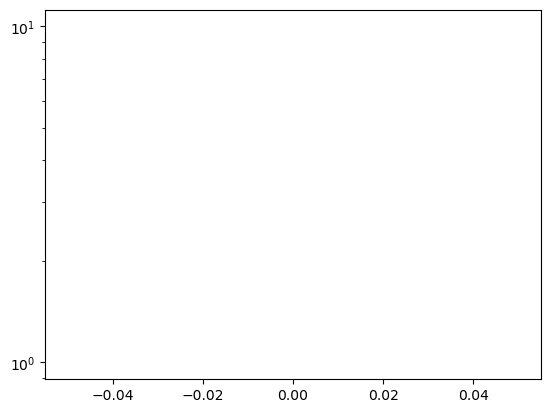

In [6]:
plt.plot(losses)
plt.yscale('log')

## new

In [7]:
net_test = VGG_BN_fullext(BN)


In [8]:
for i, child in enumerate(net_test.modules()):
    print(i,child)


0 VGG_BN_fullext(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1)

## Forward hooks

Are these the correct forward hooks?

In [9]:
# if BN:
#     relevant_param_index = [4,12,20]
# else:
#     relevant_param_index = [2,6,10]
# list_params = list(net_test.parameters())
# list_rel_params = [list_params[i] for i in range(len(list_params)) if i in relevant_param_index]
# print(len(list_rel_params))
# for i in list_rel_params: print(i.shape)

In [10]:
if BN:
    indices_rel = [5,12,19] 
else:
    indices_rel = [4,9,14]

In [11]:
# register hooks

features = {}

def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook
def get_featuresb(name):
    def hook(model, input, output):
        features[name] = output[0].detach()
    return hook
node_values_list = []
backward_values_list = []
PREDS = []
no=0
for i, child in enumerate(net_test.modules()):
    if i in indices_rel:
        child.register_forward_hook(get_features('featsf'+str(no)))   
        child.register_full_backward_hook(get_featuresb('featsb'+str(no)))
        no +=1
        node_values_list.append([])
        backward_values_list.append([])



In [12]:
for x,y in dataloader:
    net_test.zero_grad()
    y_pred = net_test(x)
    loss = loss_fn(y_pred, y)
    loss.backward()
    # collect values from forward hook
    for i in range(1, no):
            node_values_list[i -1].append(features['featsf'+str(i)])
            backward_values_list[i -1].append(features['featsb'+str(i)])


: 

In [ ]:
print(len(node_values_list))
print(no)
print(len(node_values_list[0][0]))
print(node_values_list[0][0][0].shape)

3
3


IndexError: list index out of range

In [ ]:
for x,y in dataloader:
    y_pred = net_test(x)
    loss = loss_fn(y_pred, y)
    with backpack.backpack(backpack.extensions.KFAC()):
        loss.backward()
    break



In [ ]:
kfacs = []
for i, p in enumerate(net_test.parameters()):
    if i in [6]:
        p_sel_kfac = p.kfac
        p_sel_grad = p.grad
    print(i)
    print([kfac.shape for kfac in p.kfac])
    print('gradshape',p.grad.shape)
    kfacs.append(copy.deepcopy(p.kfac))

0
[torch.Size([64, 64]), torch.Size([9, 9])]
gradshape torch.Size([64, 1, 3, 3])
1
[torch.Size([64, 64])]
gradshape torch.Size([64])
2
[torch.Size([128, 128]), torch.Size([576, 576])]
gradshape torch.Size([128, 64, 3, 3])
3
[torch.Size([128, 128])]
gradshape torch.Size([128])
4
[torch.Size([256, 256]), torch.Size([1152, 1152])]
gradshape torch.Size([256, 128, 3, 3])
5
[torch.Size([256, 256])]
gradshape torch.Size([256])
6
[torch.Size([256, 256]), torch.Size([2304, 2304])]
gradshape torch.Size([256, 256, 3, 3])
7
[torch.Size([256, 256])]
gradshape torch.Size([256])
8
[torch.Size([128, 128]), torch.Size([9216, 9216])]
gradshape torch.Size([128, 9216])
9
[torch.Size([128, 128])]
gradshape torch.Size([128])
10
[torch.Size([10, 10]), torch.Size([128, 128])]
gradshape torch.Size([10, 128])
11
[torch.Size([10, 10])]
gradshape torch.Size([10])


In [ ]:
def inverse_by_cholesky(tensor, damping):
    damped = tensor + torch.eye(tensor.shape[-1]) * damping
    cholesky = torch.cholesky(damped)
    return torch.cholesky_inverse(cholesky)

In [ ]:
def grads_to_mat(grads):
    mat = grads.reshape([grads.shape[0], grads.shape[1]*grads.shape[2]*grads.shape[3]])
    return mat

def mat_to_grads(mat):
    grad = mat.reshape([mat.shape[0],int(mat.shape[1]/9), 3,3])
    return grad

In [ ]:
V = grads_to_mat(p_sel_grad)
V.shape
p_sel_kfac[0].shape
p_sel_kfac[1].shape

torch.Size([2304, 2304])

In [ ]:
damping = 1e-1
sen_cov = inverse_by_cholesky(p_sel_kfac[0], damping)
act_cov = inverse_by_cholesky(p_sel_kfac[1], damping)
print(sen_cov.shape)
print(act_cov.shape)

torch.Size([256, 256])
torch.Size([2304, 2304])


In [ ]:
precond_grad_for_one_layer = mat_to_grads(sen_cov @ V @ act_cov)
precond_grad_for_one_layer.shape

torch.Size([256, 256, 3, 3])

In [ ]:
#from backpack.utils.kroneckers import apply_kfac_mat_prod as apply_kfac

In [ ]:
#precond_grad_for_one_layer = apply_kfac([sen_cov, act_cov], V)

RuntimeError: shape '[256, 256, 2304]' is invalid for input of size 589824

## old


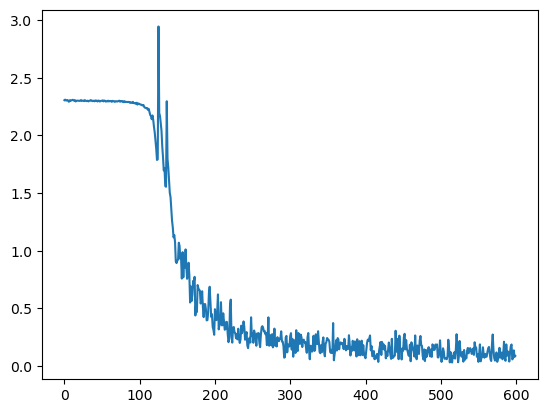

In [ ]:
plt.plot(losses)